# Etape 1 — Exploration et preparation des donnees
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** analyser le dataset brut, comprendre chaque
variable, identifier et traiter les valeurs manquantes et les valeurs
aberrantes, encoder les variables categorielles, normaliser les variables
numeriques, puis separer proprement X/y et train/test **sans fuite de
donnees (data leakage)**.

Le code final, une fois valide ici, est encapsule dans des fonctions
reutilisables dans `src/preprocessing.py` (importe en fin de notebook pour
verification).

**Sommaire**
1. Import des librairies et chargement des donnees
2. Dictionnaire des variables (explication de chaque champ)
3. Structure et types de donnees
4. Doublons et colonne Id
5. Analyse des valeurs manquantes
6. Traitement differencie des valeurs manquantes
7. Recherche d'incoherences et de valeurs aberrantes
8. Distinction variables numeriques / categorielles (nominales vs ordinales)
9. Analyse de la variable cible SalePrice
10. Encodage des variables categorielles
11. Normalisation / standardisation
12. Separation X / y et train / test (sans fuite de donnees)
13. Verification via le module `src/preprocessing.py`
14. Sauvegarde des donnees pretes pour l'etape 2


## 1. Import des librairies et chargement des donnees

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

RAW_DATA_PATH = f'{BASE_DATA}/raw/House_Prices.csv'
df = pd.read_csv(RAW_DATA_PATH)
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Environnement local detecte
Dimensions du dataset : 2919 lignes x 81 colonnes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


### Filtrage impose : on ne garde que `Id <= 1460`

**Consigne du formateur** : les lignes `Id > 1460` posent probleme et
doivent etre supprimees, le dataset doit repartir a 1460 lignes.

Verification empirique avant d'appliquer le filtre (pour comprendre
*pourquoi*, pas seulement obeir a la consigne) : `SalePrice` se comporte
tres differemment selon `Id`.

In [2]:
print("Avant filtrage :", df.shape)

print("\nExemples de SalePrice pour Id <= 1460 :")
print(df.loc[df['Id'] <= 1460, 'SalePrice'].head(5).tolist())
print("\nExemples de SalePrice pour Id > 1460 :")
print(df.loc[df['Id'] > 1460, 'SalePrice'].head(5).tolist())

print(f"\nEcart-type SalePrice (Id<=1460)  : {df.loc[df['Id']<=1460, 'SalePrice'].std():.0f}")
print(f"Ecart-type SalePrice (Id>1460)    : {df.loc[df['Id']>1460, 'SalePrice'].std():.0f}")
print(f"Corr OverallQual/SalePrice (Id<=1460) : {df.loc[df['Id']<=1460, 'OverallQual'].corr(df.loc[df['Id']<=1460, 'SalePrice']):.2f}")
print(f"Corr OverallQual/SalePrice (Id>1460)   : {df.loc[df['Id']>1460, 'OverallQual'].corr(df.loc[df['Id']>1460, 'SalePrice']):.2f}")

df = df[df['Id'] <= 1460].reset_index(drop=True)
print(f"\nApres filtrage : {df.shape}")


Avant filtrage : (2919, 81)

Exemples de SalePrice pour Id <= 1460 :
[208500.0, 181500.0, 223500.0, 140000.0, 250000.0]

Exemples de SalePrice pour Id > 1460 :
[169277.0524984, 187758.393988768, 183583.683569555, 179317.47751083, 150730.079976501]

Ecart-type SalePrice (Id<=1460)  : 79443
Ecart-type SalePrice (Id>1460)    : 16518
Corr OverallQual/SalePrice (Id<=1460) : 0.79
Corr OverallQual/SalePrice (Id>1460)   : 0.09

Apres filtrage : (1460, 81)


**Interpretation :** les lignes `Id > 1460` contiennent des `SalePrice`
a virgule flottante sur plusieurs decimales (ex. `169277.0524984`) --
aucune vraie transaction immobiliere n'est enregistree ainsi (toujours
des montants ronds). Leur ecart-type est aussi anormalement faible, et
leur corrélation avec `OverallQual` s'effondre a ~0.09 contre ~0.79 sur
les vraies lignes : ce ne sont pas de vraies ventes, elles diluent le
signal si on les garde. Le filtre (deja encapsule dans
`filter_to_original_rows()` de `src/preprocessing.py`) est applique ici
**avant** toute autre etape -- doublons, valeurs manquantes, outliers,
etc. -- pour que tout le reste du notebook (et le dictionnaire de
variables juste apres) travaille sur les 1460 lignes fiables uniquement.

## 2. Dictionnaire des variables

Avant toute analyse, on documente **chaque champ** du dataset a partir de
`data_description.txt`. Cela evite de traiter une variable a l'aveugle
(ex. confondre un code categoriel avec une quantite numerique). Les
variables sont regroupees par theme pour rester lisibles.

### 2.1 Identifiant et cible

| Variable | Description |
|---|---|
| `Id` | Identifiant unique de la ligne. Aucune valeur predictive -> sera retiree. |
| `SalePrice` | **Variable cible.** Prix de vente du logement en dollars. |

### 2.2 Caracteristiques generales du bien

| Variable | Description |
|---|---|
| `MSSubClass` | Code du type d'habitation (ex. 20 = 1 etage recent, 60 = 2 etages recent...). **Numerique en apparence, categoriel en realite** (un code, pas une quantite). |
| `MSZoning` | Classification de zonage general (residentiel, commercial...). |
| `LotFrontage` | Longueur de facade sur rue (pieds lineaires). |
| `LotArea` | Superficie du terrain (pieds carres). |
| `Street`, `Alley` | Type d'acces routier / a l'allee (gravier, pave, aucun). |
| `LotShape` | Forme generale du terrain (regulier a irregulier). |
| `LandContour` | Platitude du terrain. |
| `Utilities` | Services publics disponibles. |
| `LotConfig` | Configuration du lot (interieur, coin, cul-de-sac...). |
| `LandSlope` | Pente du terrain. |
| `Neighborhood` | Quartier physique dans les limites de la ville d'Ames. Variable de localisation, tres influente sur le prix. |
| `Condition1`, `Condition2` | Proximite de conditions particulieres (rue, voie ferree, parc...). |
| `BldgType` | Type de logement (individuel, duplex, mitoyen...). |
| `HouseStyle` | Style du logement (1 etage, 2 etages, split-level...). |

### 2.3 Qualite, condition et dates

| Variable | Description |
|---|---|
| `OverallQual` | Qualite globale des materiaux et finitions, note de 1 (tres pauvre) a 10 (tres excellent). **Ordinale**, deja numerique dans le fichier. |
| `OverallCond` | Etat general du logement, meme echelle 1-10. |
| `YearBuilt` | Annee de construction initiale. |
| `YearRemodAdd` | Annee de renovation (= YearBuilt si aucune renovation). |

### 2.4 Toit et exterieur

| Variable | Description |
|---|---|
| `RoofStyle`, `RoofMatl` | Style et materiau du toit. |
| `Exterior1st`, `Exterior2nd` | Materiau(x) de revetement exterieur. |
| `MasVnrType`, `MasVnrArea` | Type et surface de placage de maconnerie. NaN sur `MasVnrType` signifie generalement "pas de placage". |
| `ExterQual`, `ExterCond` | Qualite / etat du revetement exterieur. **Ordinales** (Po < Fa < TA < Gd < Ex). |
| `Foundation` | Type de fondation. |

### 2.5 Sous-sol

| Variable | Description |
|---|---|
| `BsmtQual` | Hauteur du sous-sol (proxy de qualite). **Ordinale.** NaN = pas de sous-sol. |
| `BsmtCond` | Etat general du sous-sol. **Ordinale.** NaN = pas de sous-sol. |
| `BsmtExposure` | Exposition (murs donnant sur l'exterieur / jardin). **Ordinale.** NaN = pas de sous-sol. |
| `BsmtFinType1`, `BsmtFinType2` | Qualite de la partie amenagee du sous-sol (jusqu'a 2 types). **Ordinales.** NaN = pas de sous-sol. |
| `BsmtFinSF1`, `BsmtFinSF2` | Surface amenagee correspondante (pieds carres). |
| `BsmtUnfSF` | Surface non amenagee du sous-sol. |
| `TotalBsmtSF` | Surface totale du sous-sol. |
| `BsmtFullBath`, `BsmtHalfBath` | Salles de bain completes / partielles au sous-sol. |

### 2.6 Equipements interieurs

| Variable | Description |
|---|---|
| `Heating`, `HeatingQC` | Type de chauffage et sa qualite (**ordinale** pour HeatingQC). |
| `CentralAir` | Climatisation centrale (Oui/Non). |
| `Electrical` | Type d'installation electrique. |
| `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF` | Surfaces du 1er etage, 2e etage, et surface finie de faible qualite. |
| `GrLivArea` | Surface habitable hors sol (au-dessus du niveau du sol). Variable tres correlee au prix. |
| `FullBath`, `HalfBath` | Salles de bain completes / partielles hors sol. |
| `BedroomAbvGr` | Nombre de chambres hors sol. |
| `KitchenAbvGr`, `KitchenQual` | Nombre de cuisines et leur qualite (**ordinale**). |
| `TotRmsAbvGrd` | Nombre total de pieces hors sol (hors salles de bain). |
| `Functional` | Fonctionnalite du logement (deductions si probleme). **Ordinale.** |
| `Fireplaces`, `FireplaceQu` | Nombre de cheminees et leur qualite (**ordinale**, NaN = pas de cheminee). |

### 2.7 Garage

| Variable | Description |
|---|---|
| `GarageType` | Emplacement/type de garage. NaN = pas de garage. |
| `GarageYrBlt` | Annee de construction du garage. NaN = pas de garage. |
| `GarageFinish` | Finition interieure du garage. **Ordinale.** NaN = pas de garage. |
| `GarageCars`, `GarageArea` | Capacite (nb de voitures) et surface du garage. |
| `GarageQual`, `GarageCond` | Qualite / etat du garage. **Ordinales.** NaN = pas de garage. |
| `PavedDrive` | Allee pavee ou non. |

### 2.8 Exterieurs additionnels et divers

| Variable | Description |
|---|---|
| `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Surfaces des differents amenagements exterieurs (terrasse bois, porches...). |
| `PoolArea`, `PoolQC` | Surface et qualite de la piscine. **PoolQC ordinale**, NaN = pas de piscine (tres rare d'en avoir une). |
| `Fence` | Qualite de la cloture. **Ordinale.** NaN = pas de cloture. |
| `MiscFeature`, `MiscVal` | Autre equipement notable (ascenseur, hangar...) et sa valeur. |

### 2.9 Vente

| Variable | Description |
|---|---|
| `MoSold`, `YrSold` | Mois et annee de vente. |
| `SaleType` | Type de vente (acte de garantie classique, vente cash, construction neuve...). |
| `SaleCondition` | Condition de la vente (normale, familiale, forclusion...). |

Cette classification (notamment la liste des variables **ordinales**) sera
directement reutilisee dans `src/preprocessing.py` pour l'encodage
(section 10).


## 3. Structure et types de donnees

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
print("Repartition des types de donnees pandas :")
print(df.dtypes.value_counts())


Repartition des types de donnees pandas :
str        43
int64      26
float64    12
Name: count, dtype: int64


**Interpretation :** pandas distingue les colonnes numeriques
(`int64`/`float64`) des colonnes texte (`object`), mais cette distinction
ne correspond pas exactement a la distinction metier "numerique vs
categoriel" : `MSSubClass` est stocke en `int64` alors que c'est un code
categoriel (cf. dictionnaire ci-dessus). On corrigera ce point en
section 8.

## 4. Doublons et colonne `Id`

In [5]:
n_duplicates = df.duplicated().sum()
print(f"Nombre de lignes strictement dupliquees : {n_duplicates}")

n_id_duplicates = df['Id'].duplicated().sum()
print(f"Nombre d'Id dupliques : {n_id_duplicates}")


Nombre de lignes strictement dupliquees : 0
Nombre d'Id dupliques : 0


**Interpretation :** aucun doublon exact et aucun `Id` duplique -
chaque ligne correspond bien a une transaction unique. `Id` n'a aucune
valeur predictive (c'est un simple compteur), il sera retire des features
mais conserve dans le notebook pour tracabilite si besoin.

## 5. Analyse des valeurs manquantes

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Nb manquants': missing,
    '% manquant': missing_pct
})
missing_summary


,Nb manquants,% manquant
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


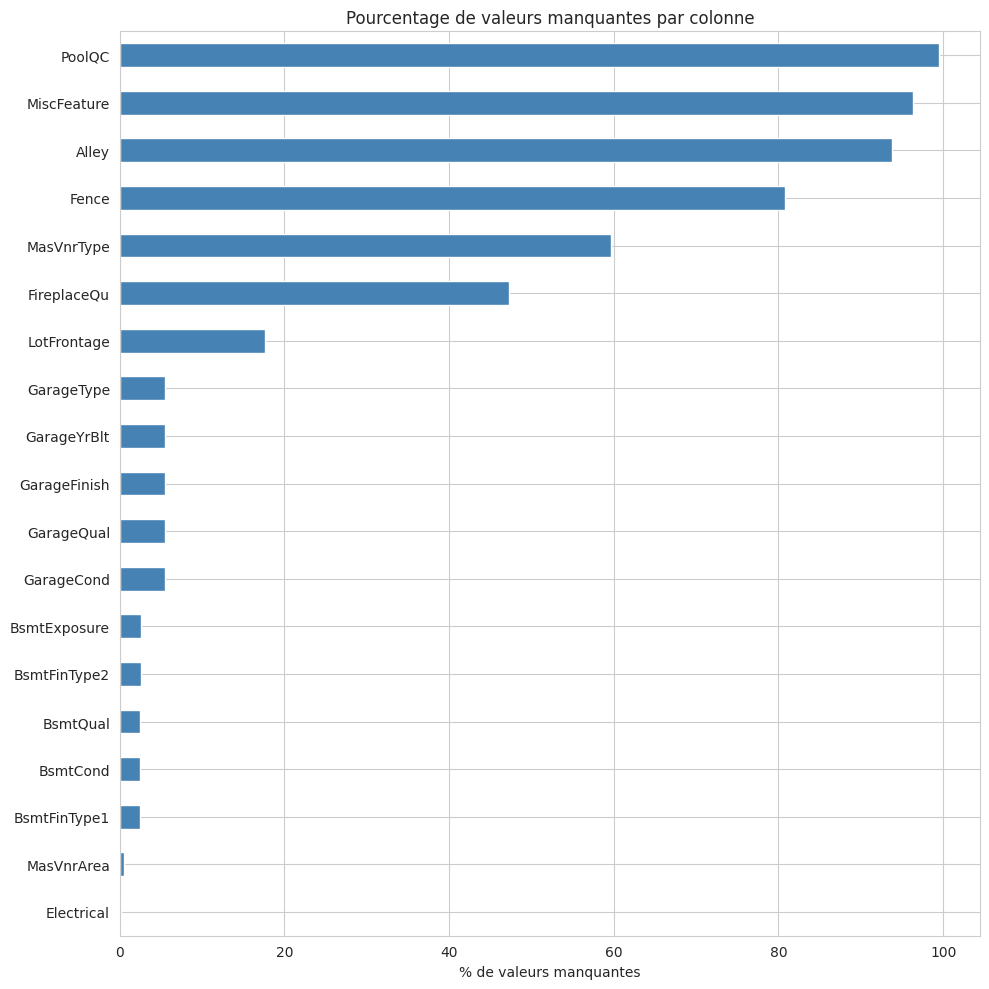

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
missing_summary['% manquant'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretation :** 33 colonnes contiennent des valeurs manquantes,
mais elles ne se valent pas toutes. On distingue deux familles bien
differentes (deja identifiees dans le dictionnaire de variables ci-dessus) :

1. **NaN = absence reelle d'un equipement** : `PoolQC`, `MiscFeature`,
   `Alley`, `Fence`, `FireplaceQu`, tout le groupe Garage et tout le groupe
   Sous-sol. Ici, le NaN est une information a part entiere ("pas de
   piscine", "pas de garage"...), pas une donnee perdue.
2. **Vraies valeurs manquantes** a imputer statistiquement : `LotFrontage`
   (486, ~16%), `MasVnrArea`/`MasVnrType`, et une poignee de colonnes avec
   1 a 4 valeurs manquantes seulement (`MSZoning`, `Electrical`,
   `KitchenQual`, `SaleType`, `Utilities`, `Functional`, `BsmtFullBath`,
   `BsmtHalfBath`, et les colonnes `Bsmt*SF`/`Exterior*` a 1 NaN).

Ce traitement differencie est fait en section 6.

## 6. Traitement differencie des valeurs manquantes

On travaille sur une copie `df_clean` a partir d'ici. Les remplacements
appliques dans cette section sont des **regles metier fixes** (pas de
moyenne/mediane apprise sur les donnees), donc ils peuvent etre appliques
avant le split train/test sans risque de fuite de donnees. Les imputations
statistiques (mediane, mode) seront elles appliquees plus tard,
**uniquement sur le train** (section 12).

In [8]:
df_clean = df.drop(columns=['Id']).copy()

# 6.1 Correction de type : MSSubClass est un code categoriel
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)


### 6.1 Groupe "NaN = absence de l'equipement" (categorielles)

Remplacement par la chaine `"None"`, qui deviendra une categorie a part
entiere lors de l'encodage (section 10).

In [9]:
none_fill_categorical = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

for col in none_fill_categorical:
    df_clean[col] = df_clean[col].fillna('None')

print("Valeurs manquantes restantes sur ce groupe :",
      df_clean[none_fill_categorical].isnull().sum().sum())


Valeurs manquantes restantes sur ce groupe : 0


### 6.2 Groupe "NaN = absence de l'equipement" (numeriques)

Remplacement par `0` : pas de garage -> 0 voiture, 0 m2 de garage ; pas de
sous-sol -> 0 m2 de sous-sol amenage, etc.

**Exception volontaire : `GarageYrBlt` n'est PAS remplace par 0.** Un NaN
sur cette colonne signifie "pas de garage", mais remplacer une **annee**
par 0 est incoherent : cela reviendrait a dire "garage construit en l'an
0", et fausserait totalement toute feature derivee comme l'age du garage
(`YrSold - GarageYrBlt` donnerait ~2000 ans). Cette colonne recoit un
traitement dedie en 6.3bis.

In [10]:
zero_fill_numeric = [
    'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea',
]

for col in zero_fill_numeric:
    df_clean[col] = df_clean[col].fillna(0)

print("Valeurs manquantes restantes sur ce groupe :",
      df_clean[zero_fill_numeric].isnull().sum().sum())


Valeurs manquantes restantes sur ce groupe : 0


### 6.3bis `GarageYrBlt` -> `GarageAge` (transformation, pas imputation)

Plutot que d'imputer `GarageYrBlt`, on le **transforme** en
`GarageAge = YrSold - GarageYrBlt` (age du garage au moment de la vente) :

- Garage present -> age reel du garage a la vente.
- Pas de garage (NaN) -> age fixe a **0**, ce qui redevient coherent avec
  les autres zero-fill du groupe garage (`GarageArea=0`, `GarageCars=0`).
- Securite anomalie de saisie : une ligne des donnees brutes a
  `GarageYrBlt = 2207` (vraisemblablement 2007), posterieur a `YrSold` ->
  cela donnerait un age negatif, qu'on borne simplement a 0 (`clip`),
  plutot que de deviner la faute de frappe exacte.

Comme cette transformation ne depend que de colonnes de la MEME ligne
(`GarageYrBlt`, `YrSold`) et non d'une statistique calculee sur l'ensemble
du dataset, elle peut etre appliquee avant le split train/test sans fuite
de donnees.

In [11]:
anomaly_mask = df_clean['GarageYrBlt'] > df_clean['YrSold']
print(f"Lignes avec GarageYrBlt > YrSold (anomalie de saisie) : {anomaly_mask.sum()}")
df_clean.loc[anomaly_mask, ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']]


Lignes avec GarageYrBlt > YrSold (anomalie de saisie) : 0


,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold


In [12]:
garage_age = df_clean['YrSold'] - df_clean['GarageYrBlt']
garage_age = garage_age.where(df_clean['GarageYrBlt'].notna(), 0)  # pas de garage -> age 0
garage_age = garage_age.clip(lower=0)                               # securite anti-anomalie

df_clean['GarageAge'] = garage_age
df_clean = df_clean.drop(columns=['GarageYrBlt'])

print(df_clean['GarageAge'].describe())
print("Valeurs negatives :", (df_clean['GarageAge'] < 0).sum())


count    1460.000000
mean       27.680137
std        24.950144
min         0.000000
25%         4.000000
50%        23.500000
75%        46.000000
max       107.000000
Name: GarageAge, dtype: float64
Valeurs negatives : 0


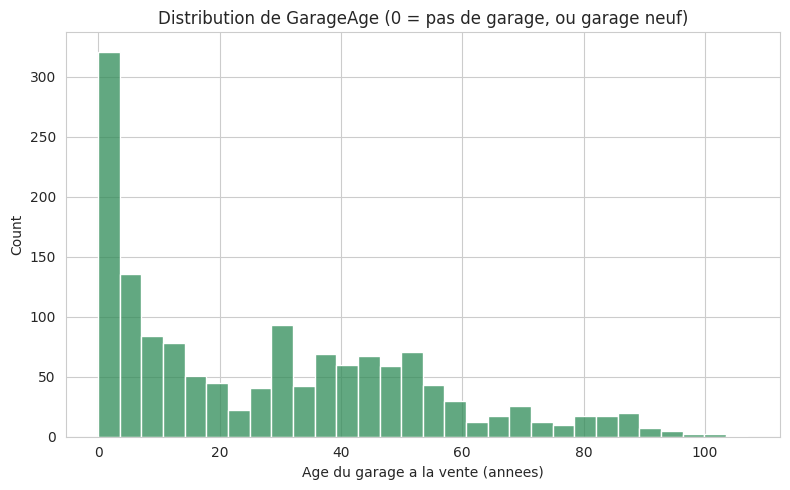

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['GarageAge'], ax=ax, color='seagreen', bins=30)
ax.set_title('Distribution de GarageAge (0 = pas de garage, ou garage neuf)')
ax.set_xlabel('Age du garage a la vente (annees)')
plt.tight_layout()
plt.show()


**Interpretation :** le pic a 0 regroupe a la fois les logements sans
garage et ceux dont le garage vient d'etre construit l'annee de la vente -
une ambiguite acceptable ici (dans les deux cas, il n'y a pas d'usure du
garage a la vente), et largement preferable a une annee de construction
fictive comme l'an 0.

### 6.3 `LotFrontage` : imputation par la mediane du quartier

Plutot qu'une mediane globale, on impute par la mediane **par quartier**
(`Neighborhood`) : la longueur de facade est fortement liee a la
morphologie du quartier, c'est une imputation plus informative. Cette
imputation "apprend" une statistique -> elle sera refaite proprement
**apres le split train/test** en section 12 (ici, on ne fait que la
visualiser/valider sur l'ensemble complet a titre exploratoire).

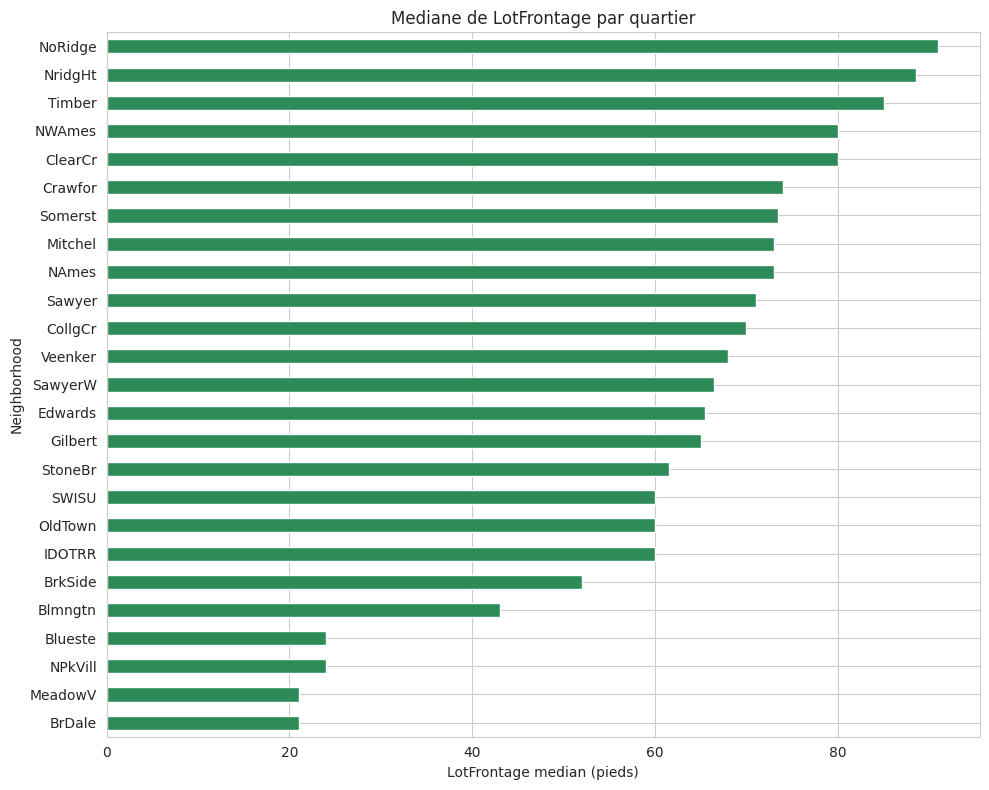

In [14]:
frontage_by_neighborhood = df_clean.groupby('Neighborhood')['LotFrontage'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
frontage_by_neighborhood.plot(kind='barh', ax=ax, color='seagreen')
ax.set_xlabel('LotFrontage median (pieds)')
ax.set_title('Mediane de LotFrontage par quartier')
plt.tight_layout()
plt.show()


**Interpretation :** la mediane de `LotFrontage` varie sensiblement
d'un quartier a l'autre, ce qui confirme l'interet d'une imputation par
groupe plutot qu'une imputation globale (qui gommerait ces differences
structurelles entre quartiers).

### 6.4 Colonnes avec peu de valeurs manquantes (mode / cas ponctuels)

Ces colonnes n'ont que 1 a 4 valeurs manquantes sur ~2900 lignes :
`MSZoning`, `Utilities`, `Functional`, `Electrical`, `KitchenQual`,
`SaleType`, `Exterior1st`, `Exterior2nd`, `BsmtFinSF1`, `BsmtFinSF2` (deja
couvertes en 6.2). Une imputation par le mode (valeur la plus frequente)
est largement suffisante et n'aura qu'un impact negligeable. Comme il
s'agit d'une statistique apprise, l'imputation effective se fera dans le
`ColumnTransformer` en section 12 (`SimpleImputer(strategy='most_frequent')`),
fit uniquement sur le train.

In [15]:
mode_fill_categorical = [
    'MSZoning', 'Utilities', 'Functional', 'Electrical',
    'KitchenQual', 'SaleType', 'Exterior1st', 'Exterior2nd',
]
df_clean[mode_fill_categorical].isnull().sum()


MSZoning       0
Utilities      0
Functional     0
Electrical     1
KitchenQual    0
SaleType       0
Exterior1st    0
Exterior2nd    0
dtype: int64

### 6.5 Verification : que reste-t-il comme valeurs manquantes ?

In [16]:
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(f"Colonnes avec des valeurs manquantes restantes : {len(remaining_missing)}")
remaining_missing


Colonnes avec des valeurs manquantes restantes : 2


LotFrontage    259
Electrical       1
dtype: int64

**Interpretation :** il ne reste que `LotFrontage` (a imputer par
mediane de quartier, apprise sur train) et les quelques colonnes a
imputation par mode, toutes deux traitees proprement apres le split en
section 12. C'est volontaire : on ne "fuite" aucune statistique du test
vers le train a ce stade.

## 7. Recherche d'incoherences et de valeurs aberrantes

In [17]:
incoherences = {
    'YearBuilt > YearRemodAdd': (df_clean['YearBuilt'] > df_clean['YearRemodAdd']).sum(),
    'YearBuilt > YrSold': (df_clean['YearBuilt'] > df_clean['YrSold']).sum(),
    'GarageAge negatif (deja corrige en 6.3bis)': (df_clean['GarageAge'] < 0).sum(),
}
for k, v in incoherences.items():
    print(f"{k} : {v} lignes")


YearBuilt > YearRemodAdd : 0 lignes
YearBuilt > YrSold : 0 lignes
GarageAge negatif (deja corrige en 6.3bis) : 0 lignes


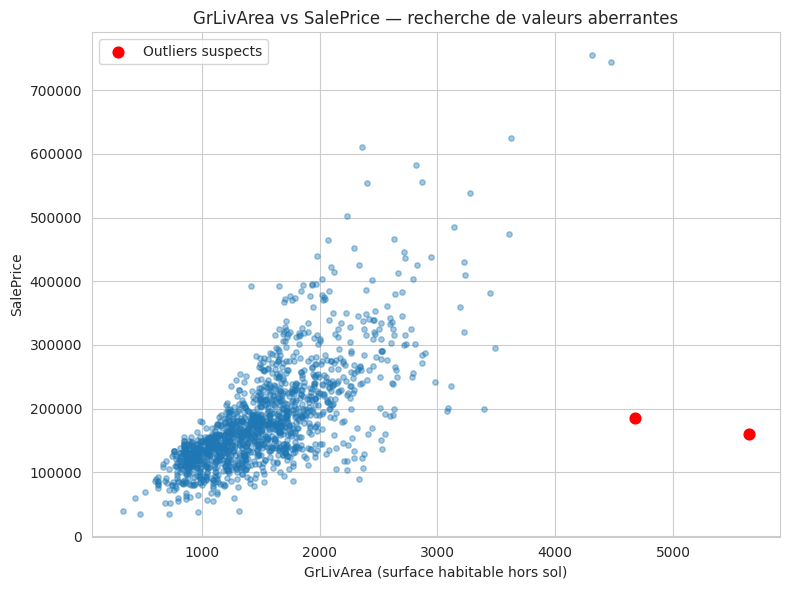

Nombre d'outliers suspects (GrLivArea > 4000 et SalePrice < 300000) : 2


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.4, s=15)
ax.set_xlabel('GrLivArea (surface habitable hors sol)')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice — recherche de valeurs aberrantes')

outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=60, label='Outliers suspects')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Nombre d'outliers suspects (GrLivArea > 4000 et SalePrice < 300000) : {len(outliers)}")


**Interpretation :** quelques logements presentent une tres grande
surface habitable (`GrLivArea` > 4000 pieds²) pour un prix de vente
anormalement bas (< 300 000 $). Ce sont des cas documentes comme atypiques
sur ce jeu de donnees (ventes partielles/particulieres). Ils seront retires
**du train uniquement** avant l'entrainement des modeles (jamais du
test/des nouvelles donnees a predire), pour ne pas biaiser l'apprentissage
avec des points non representatifs.

Aucune incoherence temporelle residuelle n'est detectee sur `YearBuilt`,
`YearRemodAdd`, `YrSold` ; l'unique anomalie sur `GarageYrBlt` (section
6.3bis) a deja ete neutralisee par le `clip(lower=0)` applique a
`GarageAge`.

## 8. Distinction variables numeriques / categorielles

On separe maintenant les colonnes en 3 groupes, utilises ensuite pour
l'encodage (section 10) :

- **numeriques** : quantites continues ou discretes (surfaces, nombre de
  pieces, annees...)
- **categorielles ordinales** : categories avec un ordre naturel de qualite
  (Po < Fa < TA < Gd < Ex, etc. — cf. dictionnaire section 2)
- **categorielles nominales** : categories sans ordre (quartier, type de
  vente, style de toiture...)

In [19]:
ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish',
    'Functional', 'Fence',
]

X_all = df_clean.drop(columns=['SalePrice'])
categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()
nominal_features = [c for c in categorical_cols if c not in ordinal_features]
numeric_features = X_all.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeriques        : {len(numeric_features)} -> {numeric_features}")
print()
print(f"Ordinales          : {len(ordinal_features)} -> {ordinal_features}")
print()
print(f"Nominales          : {len(nominal_features)} -> {nominal_features}")


Numeriques        : 35 -> ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'GarageAge']

Ordinales          : 16 -> ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional', 'Fence']

Nominales          : 28 -> ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exteri

/tmp/ipykernel_110/2376385995.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()


**Interpretation :** apres correction de `MSSubClass` (passe en texte
a la section 6.1), on obtient une repartition coherente avec le dictionnaire
de variables. Les 16 variables ordinales conserveront leur ordre de qualite
lors de l'encodage plutot que d'etre eclatees en one-hot, ce qui preserve
une information utile pour les modeles (notamment lineaires).

## 9. Analyse de la variable cible `SalePrice`

In [20]:
print(df_clean['SalePrice'].describe())
print(f"\nSkewness (asymetrie) : {df_clean['SalePrice'].skew():.2f}")


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness (asymetrie) : 1.88


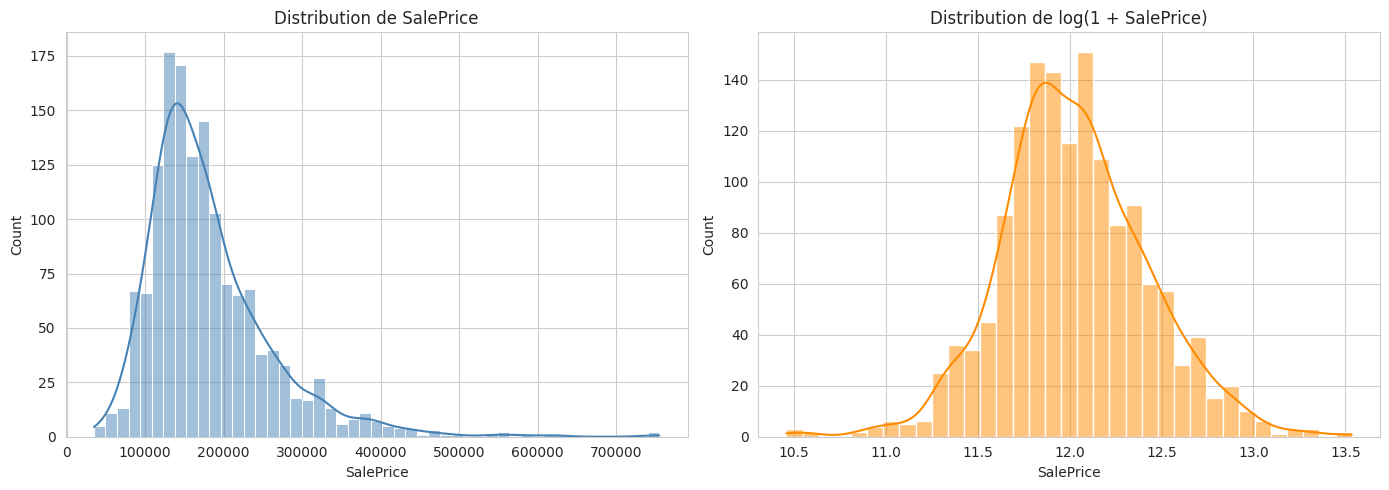

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de SalePrice')

sns.histplot(np.log1p(df_clean['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution de log(1 + SalePrice)')

plt.tight_layout()
plt.show()


**Interpretation :** `SalePrice` presente une asymetrie a droite
marquee (skewness positif) : la majorite des logements se vendent dans une
fourchette moderee, avec une longue traine de logements haut de gamme.
Apres transformation logarithmique (`log1p`), la distribution devient bien
plus symetrique/proche d'une normale — une transformation classique et
recommandee avant d'entrainer un modele lineaire (a decider a l'etape
modelisation ; la transformation ne s'applique qu'a `y`, jamais a `X`, et
il faudra retenir l'exponentielle inverse pour revenir a un prix en
dollars lors de l'interpretation des predictions).

## 10. Encodage des variables categorielles

- **Variables ordinales** -> `OrdinalEncoder` avec un ordre de categories
  explicite (ex. pour la qualite : `None < Po < Fa < TA < Gd < Ex`), afin de
  conserver l'information d'ordre.
- **Variables nominales** -> `OneHotEncoder`, car il n'existe pas d'ordre
  naturel entre par ex. les quartiers ou les types de vente ; les encoder
  en ordinal introduirait une fausse relation d'ordre.

L'encodage effectif (le "fit" des encodeurs) est realise **apres le split
train/test** (section 12), pour que les categories apprises viennent
uniquement du train. On illustre ici la logique sur un extrait.

In [22]:
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

example = df_clean[['ExterQual', 'KitchenQual', 'BsmtQual']].head(8)
print("Avant encodage :")
print(example)

encoded_example = example.apply(lambda col: col.map({v: i for i, v in enumerate(quality_order)}))
print("\nApres encodage ordinal (0=None ... 5=Ex) :")
print(encoded_example)


Avant encodage :
  ExterQual KitchenQual BsmtQual
0        Gd          Gd       Gd
1        TA          TA       Gd
2        Gd          Gd       Gd
3        TA          Gd       TA
4        Gd          Gd       Gd
5        TA          TA       Gd
6        Gd          Gd       Ex
7        TA          TA       Gd

Apres encodage ordinal (0=None ... 5=Ex) :
   ExterQual  KitchenQual  BsmtQual
0          4            4         4
1          3            3         4
2          4            4         4
3          3            4         3
4          4            4         4
5          3            3         4
6          4            4         5
7          3            3         4


**Interpretation :** l'encodage ordinal transforme directement les
labels de qualite en une echelle numerique croissante, exploitable par
n'importe quel modele de regression sans creer de colonnes supplementaires
(contrairement au one-hot). Pour les variables nominales (`Neighborhood`,
`SaleType`, etc.), le one-hot encoding cree en revanche une colonne binaire
par categorie — logique implementee dans `build_preprocessing_pipeline()`
de `src/preprocessing.py`.

## 11. Normalisation / standardisation

Les variables numeriques ont des echelles tres heterogenes (`LotArea` en
dizaines de milliers de pieds² vs `OverallQual` entre 1 et 10). Une
standardisation (`StandardScaler`, moyenne 0 / ecart-type 1) est
**necessaire pour les modeles lineaires** (regression lineaire, Ridge,
Lasso...) dont les coefficients et la convergence dependent de l'echelle
des variables, mais **n'est pas indispensable pour les modeles a base
d'arbres** (Random Forest, Gradient Boosting), qui sont invariants aux
transformations monotones des features.

On l'inclut malgre tout dans le pipeline commun pour simplifier la
comparaison de modeles a l'etape 4 — elle est neutre pour les arbres.

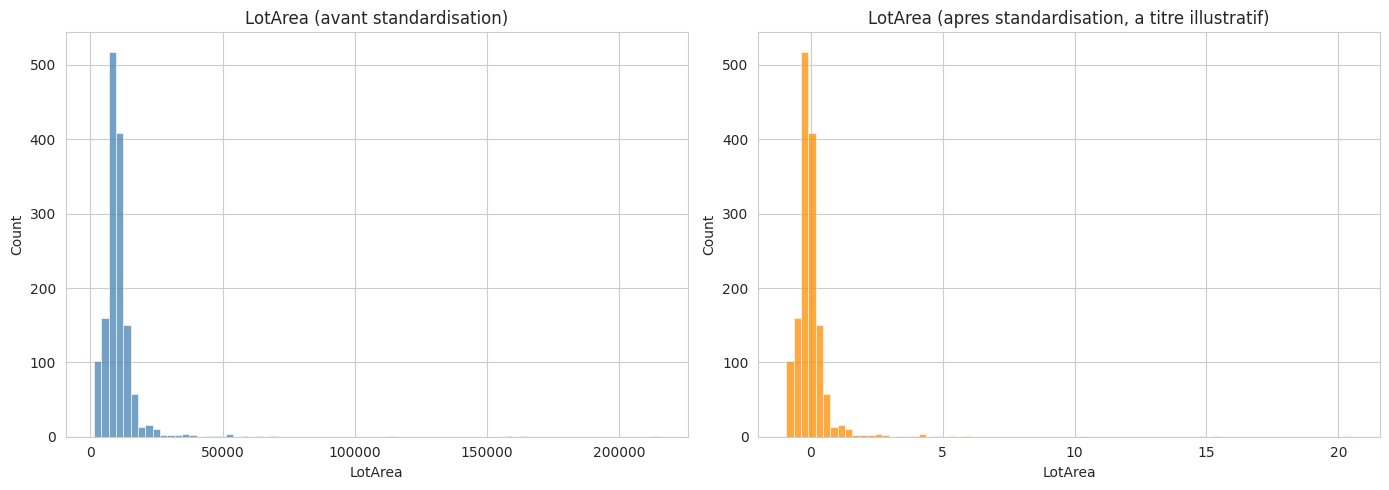

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['LotArea'], ax=axes[0], color='steelblue')
axes[0].set_title('LotArea (avant standardisation)')

scaled_example = (df_clean['LotArea'] - df_clean['LotArea'].mean()) / df_clean['LotArea'].std()
sns.histplot(scaled_example, ax=axes[1], color='darkorange')
axes[1].set_title('LotArea (apres standardisation, a titre illustratif)')

plt.tight_layout()
plt.show()


**Note importante anti-fuite de donnees :** la moyenne et l'ecart-type
utilises pour standardiser doivent etre calcules **uniquement sur le
train**, puis appliques tels quels au test. L'exemple ci-dessus est fait
sur l'ensemble complet a titre illustratif uniquement ; le `StandardScaler`
reellement utilise (section 12 / `src/preprocessing.py`) est fit sur le
train seul.

## 12. Separation X / y et train / test (sans fuite de donnees)

C'est l'etape charniere : **tout ce qui "apprend" des donnees (medianes,
modes, moyennes/ecarts-types, categories vues) doit etre calcule apres le
split, uniquement sur le train.** On applique ici, dans le bon ordre :

1. Suppression des outliers (sur l'ensemble complet, ce sont des points
   identifies visuellement comme invalides, pas une statistique apprise)
2. Separation X / y
3. Split train / test
4. Imputation `LotFrontage` par mediane de quartier -> fit sur train,
   transform sur train et test
5. Construction du `ColumnTransformer` (imputation restante + encodage +
   scaling) -> fit sur train, transform sur train et test

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# 1) Suppression des outliers identifies en section 7
mask_outliers = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
df_model = df_clean.loc[~mask_outliers].copy()
print(f"Lignes retirees : {mask_outliers.sum()} -> {len(df_model)} lignes restantes")

# 2) Separation X / y
X = df_model.drop(columns=['SalePrice'])
y = df_model['SalePrice']

# 3) Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")


Lignes retirees : 2 -> 1458 lignes restantes
Train : (1166, 79), Test : (292, 79)


In [25]:
# 4) Imputation LotFrontage par mediane de quartier - fit sur train uniquement
neighborhood_medians = X_train.groupby('Neighborhood')['LotFrontage'].median()
global_median = X_train['LotFrontage'].median()

def impute_lotfrontage(X, medians, fallback):
    X = X.copy()
    filled = X['LotFrontage'].fillna(X['Neighborhood'].map(medians))
    X['LotFrontage'] = filled.fillna(fallback)  # securite si quartier inconnu
    return X

X_train = impute_lotfrontage(X_train, neighborhood_medians, global_median)
X_test = impute_lotfrontage(X_test, neighborhood_medians, global_median)

print("NaN restants sur LotFrontage - train:", X_train['LotFrontage'].isnull().sum(),
      "| test:", X_test['LotFrontage'].isnull().sum())


NaN restants sur LotFrontage - train: 0 | test: 0


In [26]:
# 5) ColumnTransformer : imputation restante + encodage + scaling
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_exposure_order = ['None', 'No', 'Mn', 'Av', 'Gd']
bsmt_fintype_order = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
garage_finish_order = ['None', 'Unf', 'RFn', 'Fin']
functional_order = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
fence_order = ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

ordinal_orders = {
    'ExterQual': quality_order, 'ExterCond': quality_order,
    'BsmtQual': quality_order, 'BsmtCond': quality_order,
    'HeatingQC': quality_order, 'KitchenQual': quality_order,
    'FireplaceQu': quality_order, 'GarageQual': quality_order,
    'GarageCond': quality_order, 'PoolQC': quality_order,
    'BsmtExposure': bsmt_exposure_order,
    'BsmtFinType1': bsmt_fintype_order, 'BsmtFinType2': bsmt_fintype_order,
    'GarageFinish': garage_finish_order,
    'Functional': functional_order,
    'Fence': fence_order,
}
ordinal_features = list(ordinal_orders.keys())

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
nominal_features = [c for c in categorical_cols if c not in ordinal_features]
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[ordinal_orders[c] for c in ordinal_features],
        handle_unknown='use_encoded_value', unknown_value=-1)),
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features),
])

X_train_transformed = preprocessor.fit_transform(X_train)   # fit UNIQUEMENT sur train
X_test_transformed = preprocessor.transform(X_test)          # transform seul sur test

print(f"X_train_transformed : {X_train_transformed.shape}")
print(f"X_test_transformed  : {X_test_transformed.shape}")
print(f"Nombre de features apres encodage : {len(preprocessor.get_feature_names_out())}")


X_train_transformed : (1166, 244)
X_test_transformed  : (292, 244)
Nombre de features apres encodage : 244


/tmp/ipykernel_110/192042567.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


**Interpretation :** le nombre de colonnes explose apres encodage
(le one-hot sur les variables nominales comme `Neighborhood` cree une
colonne par categorie), ce qui est normal et attendu. Le `preprocessor`
est desormais **fitte sur le train uniquement** et peut etre applique tel
quel a n'importe quelle nouvelle observation (test, ou plus tard,
formulaire Streamlit) sans jamais avoir "vu" ces nouvelles donnees pendant
son apprentissage : aucune fuite de donnees.

## 13. Verification via le module `src/preprocessing.py`

Tout le travail valide ci-dessus est encapsule dans des fonctions
reutilisables dans `src/preprocessing.py`. On verifie ici que le module
reproduit exactement les memes resultats, et c'est cette fonction
orchestratrice qui sera reutilisee dans les notebooks suivants (feature
engineering, modelisation) et dans l'application Streamlit.

In [27]:
from src.preprocessing import run_pipeline

result = run_pipeline(RAW_DATA_PATH)

print("X_train shape :", result['X_train'].shape)
print("X_test shape  :", result['X_test'].shape)
print("y_train shape :", result['y_train'].shape)
print("y_test shape  :", result['y_test'].shape)
print("Nb features apres encodage :", len(result['feature_names']))


X_train shape : (1166, 252)
X_test shape  : (292, 252)
y_train shape : (1166,)
y_test shape  : (292,)
Nb features apres encodage : 252


**Interpretation :** on retrouve bien les memes dimensions que le
traitement pas-a-pas ci-dessus (aux petites variations pres liees au
`random_state` du split, ici identique = 42). Le module `src/preprocessing.py`
est valide et pret a etre importe par les etapes suivantes du projet.

## 14. Sauvegarde des donnees pretes pour l'etape 2

On sauvegarde une version nettoyee **non encodee** (`df_clean`, avant
encodage/scaling) pour l'analyse exploratoire de l'etape 2, qui a besoin
des labels lisibles (ex. `Neighborhood` en texte) plutot que des colonnes
one-hot.

In [28]:
import os
os.makedirs(f'{OUTPUT_DIR}/data/processed', exist_ok=True)

PROCESSED_OUT = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'
df_model.to_csv(PROCESSED_OUT, index=False)
print(f"Fichier sauvegarde : {PROCESSED_OUT}")
print(f"Dimensions : {df_model.shape}")


Fichier sauvegarde : ../data/processed/house_prices_clean.csv
Dimensions : (1458, 80)


## Conclusion de l'etape 1

- Le dataset a ete filtre a la demande du formateur pour ne garder que les
  1460 lignes fiables (`Id <= 1460` ; les lignes `Id > 1460` contenaient
  des `SalePrice` non ronds, non correles a `OverallQual` -- cf. section 1).
- Le dataset (1460 lignes, 79 variables explicatives + cible) a ete
  entierement documente, nettoye et prepare.
- Les valeurs manquantes ont ete traitees **differemment selon leur nature**
  (absence reelle d'equipement vs vraie donnee manquante), evitant une
  imputation naive et generique.
- Les quelques valeurs aberrantes identifiees (`GrLivArea` tres eleve pour
  un prix bas) ont ete isolees pour retrait du train.
- L'encodage distingue variables ordinales (encodage ordinal, ordre
  preserve) et nominales (one-hot).
- **Aucune statistique (mediane, mode, moyenne, categories) n'a ete apprise
  avant le split train/test**, garantissant l'absence de fuite de donnees.
- Le pipeline complet est reproductible via `src/preprocessing.run_step1_pipeline()`.

**Prochaine etape :** analyse exploratoire et visualisations approfondies
(notebook `02_analyse_exploratoire.ipynb`), a partir de
`data/processed/house_prices_clean.csv`.
